In [1]:
import earthkit as ek

In [2]:
LOCATION = [[51.42, -0.98]]

request = {
    "class": "od",
    "stream" : "enfo",
    "type" : "pf",
    "date" : -1,  # Note: date must be within the last two days 
    "time" : "0000",
    "levtype" : "sfc",
    "expver" : "0001", 
    "domain" : "g",
    "param" : "164/167/169",
    "number" : "1/to/50",
    "feature" : {
        "type" : "timeseries",
        "points": LOCATION,
        "time_axis": "step",
        "range" : {
            "start" : 0,
            "end" : 360,
        },
        "axes" : ["latitude", "longitude"]
    },
}

ds = ek.data.from_source(
    "polytope",
    "ecmwf-mars",
    request,
    stream=False,
    address='polytope.ecmwf.int',
).to_xarray()

2025-12-17 18:40:23 - INFO - Key read from /Users/mavj/.polytopeapirc
2025-12-17 18:40:23 - INFO - Sending request...
{'request': 'class: od\n'
            'date: -1\n'
            'domain: g\n'
            "expver: '0001'\n"
            'feature:\n'
            '  axes:\n'
            '  - latitude\n'
            '  - longitude\n'
            '  points:\n'
            '  - - 51.42\n'
            '    - -0.98\n'
            '  range:\n'
            '    end: 360\n'
            '    start: 0\n'
            '  time_axis: step\n'
            '  type: timeseries\n'
            'levtype: sfc\n'
            'number: 1/to/50\n'
            'param: 164/167/169\n'
            'stream: enfo\n'
            "time: '0000'\n"
            'type: pf\n',
 'verb': 'retrieve'}
2025-12-17 18:40:23 - INFO - Polytope user key found in session cache for user mavj
2025-12-17 18:40:25 - INFO - Request accepted. Please poll ./84f21272-bc38-472e-aba5-d49aa21f1bdc for status
2025-12-17 18:40:25 - INFO - Polytope 

In [3]:
ds.squeeze()

<xarray.Dataset> Size: 176kB
Dimensions:    (number: 50, t: 145)
Coordinates:
  * number     (number) int64 400B 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50
  * t          (t) datetime64[ns] 1kB 2025-12-16 ... 2025-12-31
    latitude   float64 8B 51.42
    longitude  float64 8B 359.0
    levelist   int64 8B 0
    datetime   <U20 80B '2025-12-16T00:00:00Z'
Data variables:
    tcc        (number, t) float64 58kB 0.9974 0.9993 0.9977 1.0 ... 1.0 1.0 1.0
    2t         (number, t) float64 58kB 283.1 282.8 283.0 ... 284.5 283.8 283.8
    ssrd       (number, t) float64 58kB 0.0 0.0 0.0 ... 3.46e+07 3.46e+07
Attributes:
    class:          od
    Forecast date:  2025-12-16T00:00:00Z
    domain:         g
    expver:         0001
    levtype:        sfc
    number:         1
    stream:         enfo
    type:           pf
    levelist:       0

/Users/mavj/ek-plots-fix/earthkit-plots/src/earthkit/plots/temporal/timeseries.py:570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  self.ax.set_xticklabels(new_labels, minor=True)


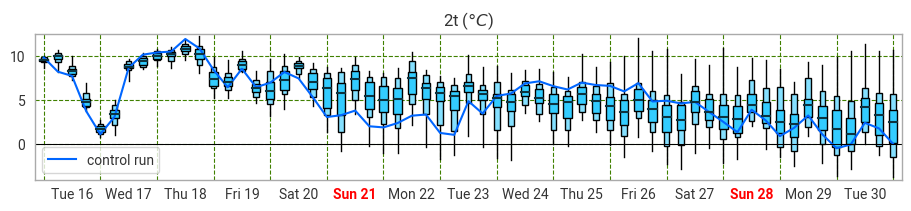

In [4]:
chart = ek.plots.TimeSeries(size=(9, 2))

chart.multiboxplot(
    ds["2t"],
    units="celsius",
    resample_time="6h",
    color="#33ccff",
)

chart.line(
    ds["2t"].isel(number=0),
    units="celsius",
    resample_time="6h",
    label="control run",
    color="#0066ff",
)

chart.title("{variable_name} ({units})")

chart.xticks(
    frequency="D",
    period=True,
    highlight_frequency="W",
    highlight_color="red",
    format="%a %-d"
)

chart.ax.grid(color="#408000", linestyle="--")
chart.ax.axhline(color="k", linewidth=0.75)

chart.legend(location="lower left")

chart.show()